# 🏥 Heart Disease Prediction System
**CodeAlpha Machine Learning Internship — Task 4**

**Developer: Taj Wali Khan**


A professional-grade version of the disease-prediction project: cleaner
architecture, more models, real explainability, an adjustable decision
threshold, batch predictions from CSV, downloadable reports, and a redesigned,
attractive Gradio interface — with the developer's name shown clearly in the UI.

### 🐛 Bugs fixed from the original version
1. **Chained in-place `fillna`** (`X[col].fillna(..., inplace=True)`) triggers a
   `SettingWithCopyWarning` / silently-ignored update on newer pandas versions
   because `X[col]` returns a view, not a guaranteed reference back to `X`.
   Fixed with `X[col] = X[col].fillna(...)`.
2. **Manual "if model needs scaling" branching** scattered through training,
   cross-validation, and prediction code — easy to forget when adding a new
   model (a silent, hard-to-notice bug). Fixed by wrapping every model that
   needs scaling in an sklearn `Pipeline([("scaler", StandardScaler()), ("clf", ...)])`.
   Every model now trains, cross-validates, and predicts the exact same way —
   no branching required anywhere in the notebook.
3. **Hardcoded 4-item color list** (`MODEL_COLORS = [...]`) broke as soon as a
   5th model was added. Replaced with a `matplotlib` colormap that scales to
   any number of models automatically.
4. **Feature importance panel hardcoded to exactly 2 models** (Random Forest,
   XGBoost). Now auto-detects every trained model that exposes
   `feature_importances_` and builds one panel per model.

### ✨ New features added
- **7 trained models** instead of 4: Logistic Regression, Random Forest,
  Gradient Boosting, XGBoost, SVM, KNN, and a soft-voting **Ensemble** of the
  first four.
- **Optional automatic hyperparameter tuning** (`ADVANCED_TUNING` toggle) using
  `RandomizedSearchCV` for Random Forest and XGBoost.
- **Adjustable decision threshold** — a live slider that controls how
  sensitive the diagnosis is, independent of which model is used.
- **Model selector** — predict with *any* of the 7 trained models, or let the
  app auto-pick the best one.
- **Explainability engine** — SHAP-based local explanations when available,
  with an automatic, dependency-free fallback so the app never breaks.
- **Visual risk gauge** — a color-banded semicircle meter for each prediction.
- **Batch prediction** — upload a CSV of many patients, get a downloadable
  results file.
- **Downloadable text report** for any single prediction.
- **Session prediction history** table.
- **A 6th evaluation metric** (Average Precision) added throughout, useful for
  imbalanced medical datasets.
- **Redesigned, attractive UI** with a gradient header, metric badges, and the
  developer's name shown clearly in the interface.


In [1]:
# CELL 1 - Install core dependencies
# Note: Colab already ships numpy / pandas / matplotlib / scikit-learn,
# but we pin the install anyway so this notebook is portable to a fresh
# environment too.
!pip install -q xgboost scikit-learn matplotlib seaborn pandas gradio joblib
print("Core dependencies ready")


Core dependencies ready


In [2]:
# CELL 2 - Install SHAP (optional, isolated so a failure here never
# blocks the rest of the notebook - the app falls back gracefully if
# SHAP is unavailable).
try:
    get_ipython().system('pip install -q shap')
    print("SHAP installation attempted")
except Exception as e:
    print(f"Skipped SHAP install: {e}")


SHAP installation attempted


In [3]:
# CELL 3 - Imports, configuration, reproducibility
import os, io, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Wedge, Circle
from matplotlib import cm
import seaborn as sns
from PIL import Image
import joblib

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve,
    classification_report, confusion_matrix
)
from xgboost import XGBClassifier
import gradio as gr

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

# ── Reproducibility ────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Toggles ─────────────────────────────────────────────────────
ADVANCED_TUNING = True     # RandomizedSearchCV for RF & XGBoost (small search, ~10-20s)
TEST_SIZE = 0.20
DEFAULT_THRESHOLD = 0.50

DEVELOPER_NAME = "Taj Wali Khan"
PROJECT_TITLE = "Heart Disease Prediction System"

# ── Colour palette ──────────────────────────────────────────────
COLORS = {
    "primary": "#6366F1", "success": "#10B981", "danger": "#EF4444",
    "warning": "#F59E0B", "info": "#0EA5E9", "purple": "#8B5CF6",
}

print("=" * 60)
print(f"  CodeAlpha ML Internship - Task 4: {PROJECT_TITLE}")
print(f"  Developer: {DEVELOPER_NAME}")
print("=" * 60)
print(f"  Pandas       : {pd.__version__}")
print(f"  Gradio       : {gr.__version__}")
print(f"  SHAP         : {'available' if SHAP_AVAILABLE else 'not available (fallback explainer will be used)'}")
print(f"  ADVANCED_TUNING: {ADVANCED_TUNING}")
print("=" * 60)


  CodeAlpha ML Internship - Task 4: Heart Disease Prediction System
  Developer: Taj Wali Khan
  Pandas       : 2.2.2
  Gradio       : 6.19.0
  SHAP         : available
  ADVANCED_TUNING: True


## Part 1 — Load the Dataset
Cleveland Heart Disease dataset (UCI ML Repository), 303 patients, 13 clinical
features, binary target (1 = heart disease present, 0 = no disease).

In [4]:
# CELL 4 - Robust dataset loader with two online mirrors + offline fallback
def _create_sample_dataset(n=303):
    """Small synthetic dataset used only if both online sources fail."""
    rng = np.random.RandomState(RANDOM_STATE)
    data = {
        "age": rng.randint(29, 77, n), "sex": rng.randint(0, 2, n),
        "cp": rng.randint(0, 4, n), "trestbps": rng.randint(94, 200, n),
        "chol": rng.randint(126, 564, n), "fbs": rng.randint(0, 2, n),
        "restecg": rng.randint(0, 3, n), "thalach": rng.randint(71, 202, n),
        "exang": rng.randint(0, 2, n), "oldpeak": np.round(rng.uniform(0, 6.2, n), 1),
        "slope": rng.randint(0, 3, n), "ca": rng.randint(0, 4, n),
        "thal": rng.randint(0, 3, n), "target": rng.randint(0, 2, n),
    }
    return pd.DataFrame(data)


def load_heart_disease_data():
    urls = [
        "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv",
        "https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv",
    ]
    df, source = None, None
    for url in urls:
        try:
            df = pd.read_csv(url)
            source = url
            break
        except Exception:
            continue

    if df is None:
        print("  Online sources unavailable - generating a reproducible sample dataset")
        df = _create_sample_dataset()
        source = "synthetic fallback"

    rename_map = {
        "age": "age", "sex": "sex", "cp": "chest_pain", "trestbps": "blood_pressure",
        "chol": "cholesterol", "fbs": "blood_sugar", "restecg": "ecg",
        "thalach": "max_heart_rate", "exang": "exercise_angina",
        "oldpeak": "st_depression", "slope": "slope", "ca": "vessels",
        "thal": "thal", "target": "target",
    }
    df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns}, inplace=True)

    if df["target"].max() > 1:
        df["target"] = (df["target"] > 0).astype(int)

    print(f"Dataset loaded from: {source}")
    print(f"  Rows    : {df.shape[0]} patients")
    print(f"  Columns : {df.shape[1]} features")
    print(f"  Target 0 (No Disease)    : {(df['target']==0).sum()}")
    print(f"  Target 1 (Heart Disease) : {(df['target']==1).sum()}")
    return df

df_raw = load_heart_disease_data()
df_raw.head(3)


Dataset loaded from: https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv
  Rows    : 303 patients
  Columns : 14 features
  Target 0 (No Disease)    : 138
  Target 1 (Heart Disease) : 165


,age,sex,chest_pain,blood_pressure,cholesterol,blood_sugar,ecg,max_heart_rate,exercise_angina,st_depression,slope,vessels,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1


## Part 2 — Exploratory Data Analysis

In [5]:
# CELL 5 - EDA summary
print("Dataset shape:", df_raw.shape)
print("\nMissing values per column:")
missing = df_raw.isnull().sum()
print("  None found" if missing.sum() == 0 else missing[missing > 0].to_string())

print("\nBasic statistics:")
print(df_raw.describe().round(2).to_string())

disease_count = (df_raw["target"] == 1).sum()
no_disease_count = (df_raw["target"] == 0).sum()
total = len(df_raw)
print(f"\nClass distribution: Heart Disease {disease_count} ({disease_count/total*100:.1f}%) | "
      f"No Disease {no_disease_count} ({no_disease_count/total*100:.1f}%)")

# Quick outlier scan (IQR method) - informational only, no rows are dropped
print("\nOutlier scan (IQR method, informational only):")
for col in df_raw.select_dtypes(include=[np.number]).columns:
    if col == "target":
        continue
    q1, q3 = df_raw[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df_raw[col] < q1 - 1.5 * iqr) | (df_raw[col] > q3 + 1.5 * iqr)).sum()
    if n_out > 0:
        print(f"  {col:<18}: {n_out} potential outliers")


Dataset shape: (303, 14)

Missing values per column:
  None found

Basic statistics:
          age     sex  chest_pain  blood_pressure  cholesterol  blood_sugar     ecg  max_heart_rate  exercise_angina  st_depression   slope  vessels    thal  target
count  303.00  303.00      303.00          303.00       303.00       303.00  303.00          303.00           303.00         303.00  303.00   303.00  303.00  303.00
mean    54.37    0.68        0.97          131.62       246.26         0.15    0.53          149.65             0.33           1.04    1.40     0.73    2.31    0.54
std      9.08    0.47        1.03           17.54        51.83         0.36    0.53           22.91             0.47           1.16    0.62     1.02    0.61    0.50
min     29.00    0.00        0.00           94.00       126.00         0.00    0.00           71.00             0.00           0.00    0.00     0.00    0.00    0.00
25%     47.50    0.00        0.00          120.00       211.00         0.00    0.00       

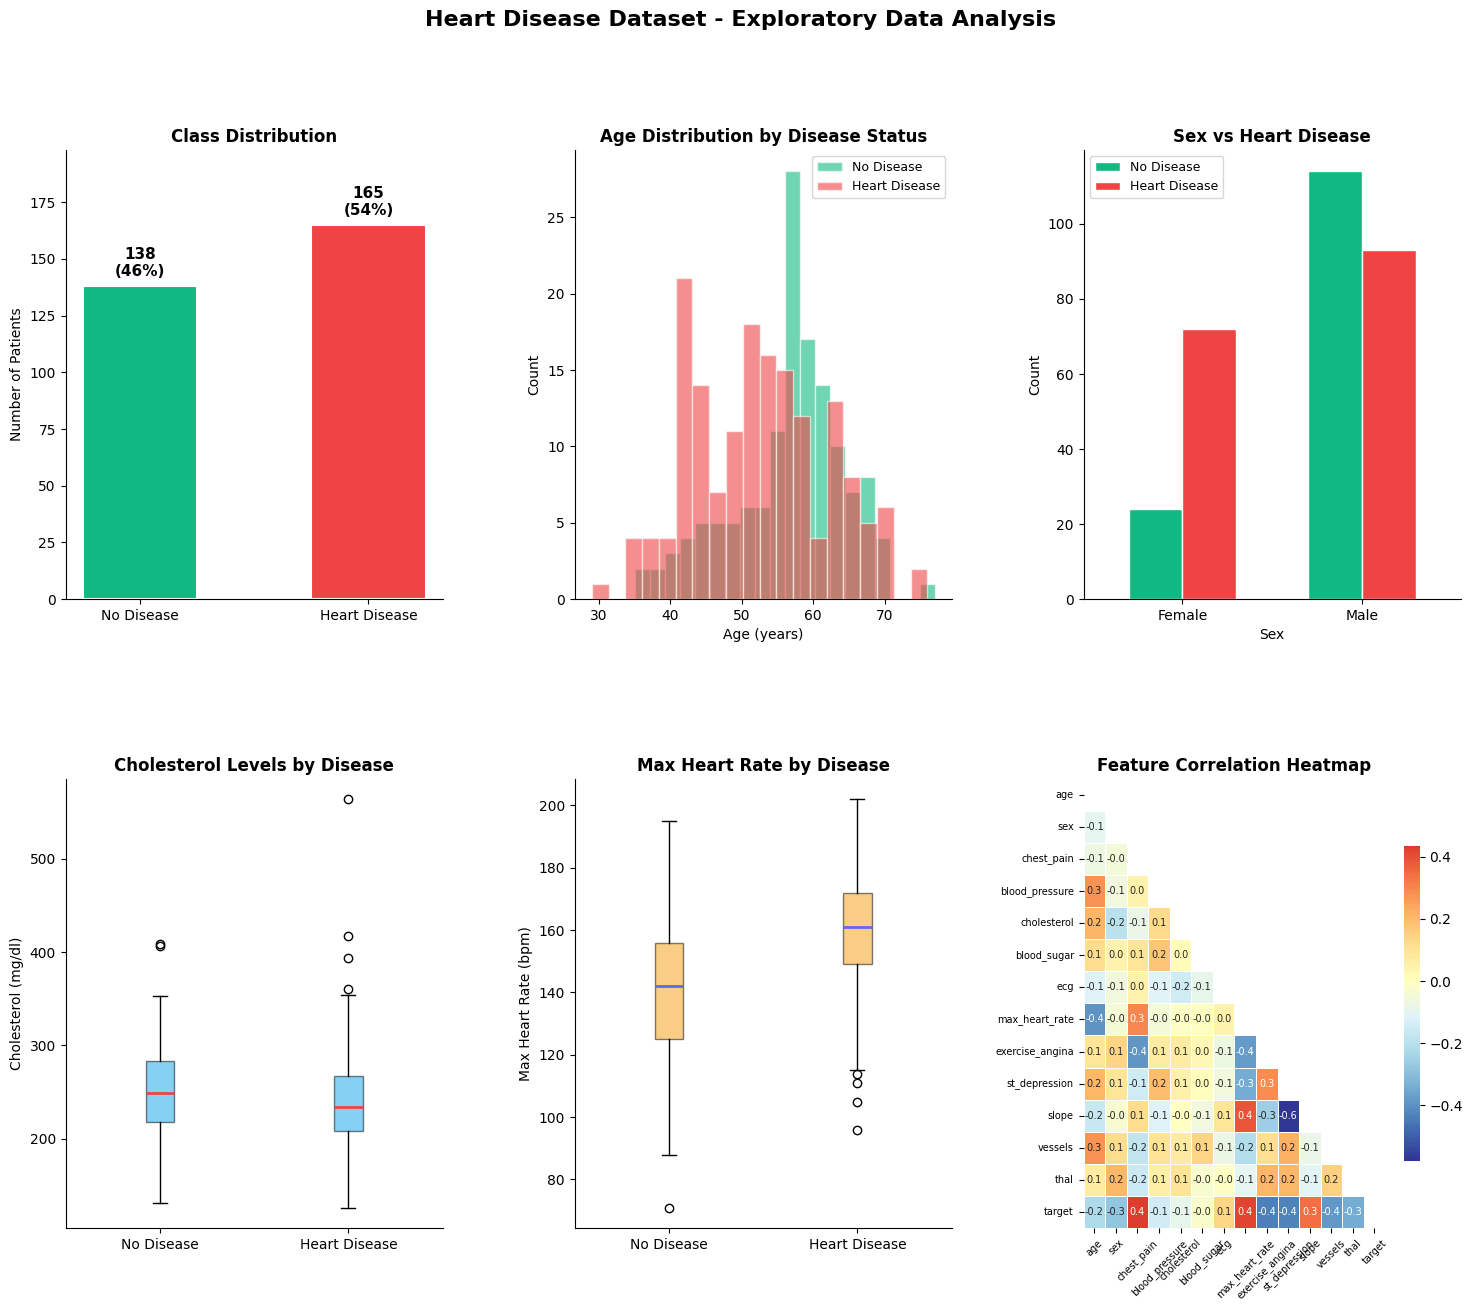

EDA charts saved


In [6]:
# CELL 6 - EDA visualizations (6-panel dashboard)
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Heart Disease Dataset - Exploratory Data Analysis", fontsize=16, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
counts = [no_disease_count, disease_count]
bars = ax1.bar(["No Disease", "Heart Disease"], counts,
                color=[COLORS["success"], COLORS["danger"]], width=0.5, edgecolor="white", linewidth=1.5)
ax1.set_title("Class Distribution", fontweight="bold", fontsize=12)
ax1.set_ylabel("Number of Patients")
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
              f"{count}\n({count/total*100:.0f}%)", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax1.spines[["top", "right"]].set_visible(False)
ax1.set_ylim(0, max(counts) * 1.2)

ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df_raw[df_raw["target"] == 0]["age"], bins=20, alpha=0.6, color=COLORS["success"], label="No Disease", edgecolor="white")
ax2.hist(df_raw[df_raw["target"] == 1]["age"], bins=20, alpha=0.6, color=COLORS["danger"], label="Heart Disease", edgecolor="white")
ax2.set_title("Age Distribution by Disease Status", fontweight="bold", fontsize=12)
ax2.set_xlabel("Age (years)"); ax2.set_ylabel("Count"); ax2.legend(fontsize=9)
ax2.spines[["top", "right"]].set_visible(False)

ax3 = fig.add_subplot(gs[0, 2])
sex_disease = df_raw.groupby(["sex", "target"]).size().unstack(fill_value=0)
sex_disease.index = ["Female", "Male"]
sex_disease.columns = ["No Disease", "Heart Disease"]
sex_disease.plot(kind="bar", ax=ax3, color=[COLORS["success"], COLORS["danger"]], edgecolor="white", width=0.6)
ax3.set_title("Sex vs Heart Disease", fontweight="bold", fontsize=12)
ax3.set_xlabel("Sex"); ax3.set_ylabel("Count"); ax3.tick_params(axis="x", rotation=0); ax3.legend(fontsize=9)
ax3.spines[["top", "right"]].set_visible(False)

ax4 = fig.add_subplot(gs[1, 0])
ax4.boxplot([df_raw[df_raw["target"] == 0]["cholesterol"].dropna(), df_raw[df_raw["target"] == 1]["cholesterol"].dropna()],
            labels=["No Disease", "Heart Disease"], patch_artist=True,
            boxprops=dict(facecolor=COLORS["info"], alpha=0.5), medianprops=dict(color=COLORS["danger"], linewidth=2))
ax4.set_title("Cholesterol Levels by Disease", fontweight="bold", fontsize=12)
ax4.set_ylabel("Cholesterol (mg/dl)"); ax4.spines[["top", "right"]].set_visible(False)

ax5 = fig.add_subplot(gs[1, 1])
ax5.boxplot([df_raw[df_raw["target"] == 0]["max_heart_rate"].dropna(), df_raw[df_raw["target"] == 1]["max_heart_rate"].dropna()],
            labels=["No Disease", "Heart Disease"], patch_artist=True,
            boxprops=dict(facecolor=COLORS["warning"], alpha=0.5), medianprops=dict(color=COLORS["primary"], linewidth=2))
ax5.set_title("Max Heart Rate by Disease", fontweight="bold", fontsize=12)
ax5.set_ylabel("Max Heart Rate (bpm)"); ax5.spines[["top", "right"]].set_visible(False)

ax6 = fig.add_subplot(gs[1, 2])
corr_matrix = df_raw.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=ax6, cmap="RdYlBu_r", center=0, fmt=".1f",
            annot=True, annot_kws={"size": 7}, linewidths=0.5, linecolor="white", cbar_kws={"shrink": 0.7})
ax6.set_title("Feature Correlation Heatmap", fontweight="bold", fontsize=12)
ax6.tick_params(axis="x", rotation=45, labelsize=7); ax6.tick_params(axis="y", rotation=0, labelsize=7)

plt.savefig("/content/eda_charts.png", dpi=120, bbox_inches="tight", facecolor="white")
plt.show()
print("EDA charts saved")


## Part 3 — Preprocessing

In [7]:
# CELL 7 - Preprocess (BUG FIXED: no more chained in-place fillna)
df = df_raw.copy()
X = df.drop(columns=["target"]).copy()
y = df["target"].copy()
FEATURE_NAMES = list(X.columns)

print(f"Features used ({len(FEATURE_NAMES)}):")
for i, name in enumerate(FEATURE_NAMES):
    print(f"  {i+1:2d}. {name}")

missing_count = X.isnull().sum().sum()
if missing_count > 0:
    print(f"\nFound {missing_count} missing values - filling with median")
    for col in X.columns:
        if X[col].isnull().any():
            # FIX: reassign instead of chained inplace=True (avoids
            # SettingWithCopyWarning / silently-not-applied updates)
            X[col] = X[col].fillna(X[col].median())
else:
    print("\nNo missing values to handle")

for col in X.columns:
    if X[col].dtype == "object":
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
        print(f"  Encoded non-numeric column: {col}")

print(f"\nX shape: {X.shape} | y shape: {y.shape}")
print("Preprocessing complete")


Features used (13):
   1. age
   2. sex
   3. chest_pain
   4. blood_pressure
   5. cholesterol
   6. blood_sugar
   7. ecg
   8. max_heart_rate
   9. exercise_angina
  10. st_depression
  11. slope
  12. vessels
  13. thal

No missing values to handle

X shape: (303, 13) | y shape: (303,)
Preprocessing complete


In [8]:
# CELL 8 - Train/test split
# NOTE: unlike the original version, we do NOT create a global scaled
# copy here. Scaling is now handled per-model inside sklearn Pipelines
# (see Part 4), which removes an entire class of bugs where a new model
# forgets to use the scaled data.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# A reference scaler + per-feature mean/std, used only by the
# explainability engine later (Part 6) to judge how unusual a patient's
# values are compared to the training population - never fed to a model.
REFERENCE_SCALER = StandardScaler().fit(X_train)
TRAIN_MEAN = X_train.mean()
TRAIN_STD = X_train.std().replace(0, 1)

print(f"Training set: {X_train.shape[0]} patients ({y_train.sum()} disease / {(y_train==0).sum()} no disease)")
print(f"Test set    : {X_test.shape[0]} patients ({y_test.sum()} disease / {(y_test==0).sum()} no disease)")


Training set: 242 patients (132 disease / 110 no disease)
Test set    : 61 patients (33 disease / 28 no disease)


## Part 4 — Model Training (7 Models)
Every model that needs scaled input (Logistic Regression, SVM, KNN) is
wrapped in an sklearn `Pipeline` with its own `StandardScaler`. Tree-based
models (Random Forest, Gradient Boosting, XGBoost) take raw features. This
means training, cross-validation, and prediction code below never needs to
branch on "does this model need scaling?" — the pipeline handles it.

In [9]:
# CELL 9 - Base model definitions
base_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, C=1.0)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        random_state=RANDOM_STATE, eval_metric="logloss", verbosity=0
    ),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", C=1.0, probability=True, random_state=RANDOM_STATE)),
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=9)),
    ]),
}
print(f"{len(base_models)} base models defined: {list(base_models.keys())}")


6 base models defined: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'SVM', 'KNN']


In [10]:
# CELL 10 - Optional automatic hyperparameter tuning (NEW FEATURE)
if ADVANCED_TUNING:
    from scipy.stats import randint, uniform
    print("Running RandomizedSearchCV for Random Forest and XGBoost...\n")

    rf_search = RandomizedSearchCV(
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        param_distributions={
            "n_estimators": randint(100, 400),
            "max_depth": randint(4, 14),
            "min_samples_split": randint(2, 10),
            "min_samples_leaf": randint(1, 6),
        },
        n_iter=8, cv=3, scoring="roc_auc", random_state=RANDOM_STATE, n_jobs=-1,
    ).fit(X_train, y_train)
    base_models["Random Forest"] = rf_search.best_estimator_
    print(f"  Random Forest best params : {rf_search.best_params_}")
    print(f"  Random Forest best CV AUC : {rf_search.best_score_:.3f}")

    xgb_search = RandomizedSearchCV(
        XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", verbosity=0),
        param_distributions={
            "n_estimators": randint(100, 400),
            "max_depth": randint(3, 8),
            "learning_rate": uniform(0.02, 0.28),
            "subsample": uniform(0.7, 0.3),
            "colsample_bytree": uniform(0.7, 0.3),
        },
        n_iter=8, cv=3, scoring="roc_auc", random_state=RANDOM_STATE, n_jobs=-1,
    ).fit(X_train, y_train)
    base_models["XGBoost"] = xgb_search.best_estimator_
    print(f"  XGBoost best params       : {xgb_search.best_params_}")
    print(f"  XGBoost best CV AUC       : {xgb_search.best_score_:.3f}")
else:
    print("ADVANCED_TUNING is off - using default hyperparameters")


Running RandomizedSearchCV for Random Forest and XGBoost...

  Random Forest best params : {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 6, 'n_estimators': 260}
  Random Forest best CV AUC : 0.912
  XGBoost best params       : {'colsample_bytree': np.float64(0.8834959481464842), 'learning_rate': np.float64(0.021978565461520876), 'max_depth': 3, 'n_estimators': 148, 'subsample': np.float64(0.8574323980775167)}
  XGBoost best CV AUC       : 0.898


In [11]:
# CELL 11 - Build the soft-voting Ensemble on top of the tuned base models
voting_estimators = [(name, base_models[name]) for name in
                      ["Logistic Regression", "Random Forest", "XGBoost", "SVM"]]
base_models["Voting Ensemble"] = VotingClassifier(estimators=voting_estimators, voting="soft")

models = base_models
print(f"Final model roster ({len(models)}): {list(models.keys())}")


Final model roster (7): ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'SVM', 'KNN', 'Voting Ensemble']


In [12]:
# CELL 12 - Train all models and evaluate on the held-out test set
results = {}
trained_models = {}

print("Training all models...\n")
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    elapsed = time.time() - t0

    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "avg_precision": average_precision_score(y_test, y_prob),
        "y_pred": y_pred, "y_pred_prob": y_prob,
    }
    trained_models[name] = model
    print(f"  {name:<22} done in {elapsed:5.2f}s | "
          f"Acc: {results[name]['accuracy']:.3f}  AUC: {results[name]['roc_auc']:.3f}")

model_names = list(results.keys())
BEST_MODEL_NAME = max(results, key=lambda m: results[m]["roc_auc"])
best_model = trained_models[BEST_MODEL_NAME]

print(f"\nAll {len(models)} models trained")
print(f"Best model: {BEST_MODEL_NAME}  (AUC = {results[BEST_MODEL_NAME]['roc_auc']:.3f})")


Training all models...

  Logistic Regression    done in  0.10s | Acc: 0.803  AUC: 0.869
  Random Forest          done in  1.05s | Acc: 0.803  AUC: 0.906
  Gradient Boosting      done in  0.65s | Acc: 0.803  AUC: 0.873
  XGBoost                done in  0.12s | Acc: 0.836  AUC: 0.904
  SVM                    done in  0.05s | Acc: 0.820  AUC: 0.883
  KNN                    done in  0.02s | Acc: 0.820  AUC: 0.890
  Voting Ensemble        done in  1.33s | Acc: 0.820  AUC: 0.899

All 7 models trained
Best model: Random Forest  (AUC = 0.906)


## Part 5 — Model Comparison & Visualization
All charts below are written to automatically scale to however many models
were trained — add or remove a model in Part 4 and these cells keep working
with no changes needed.

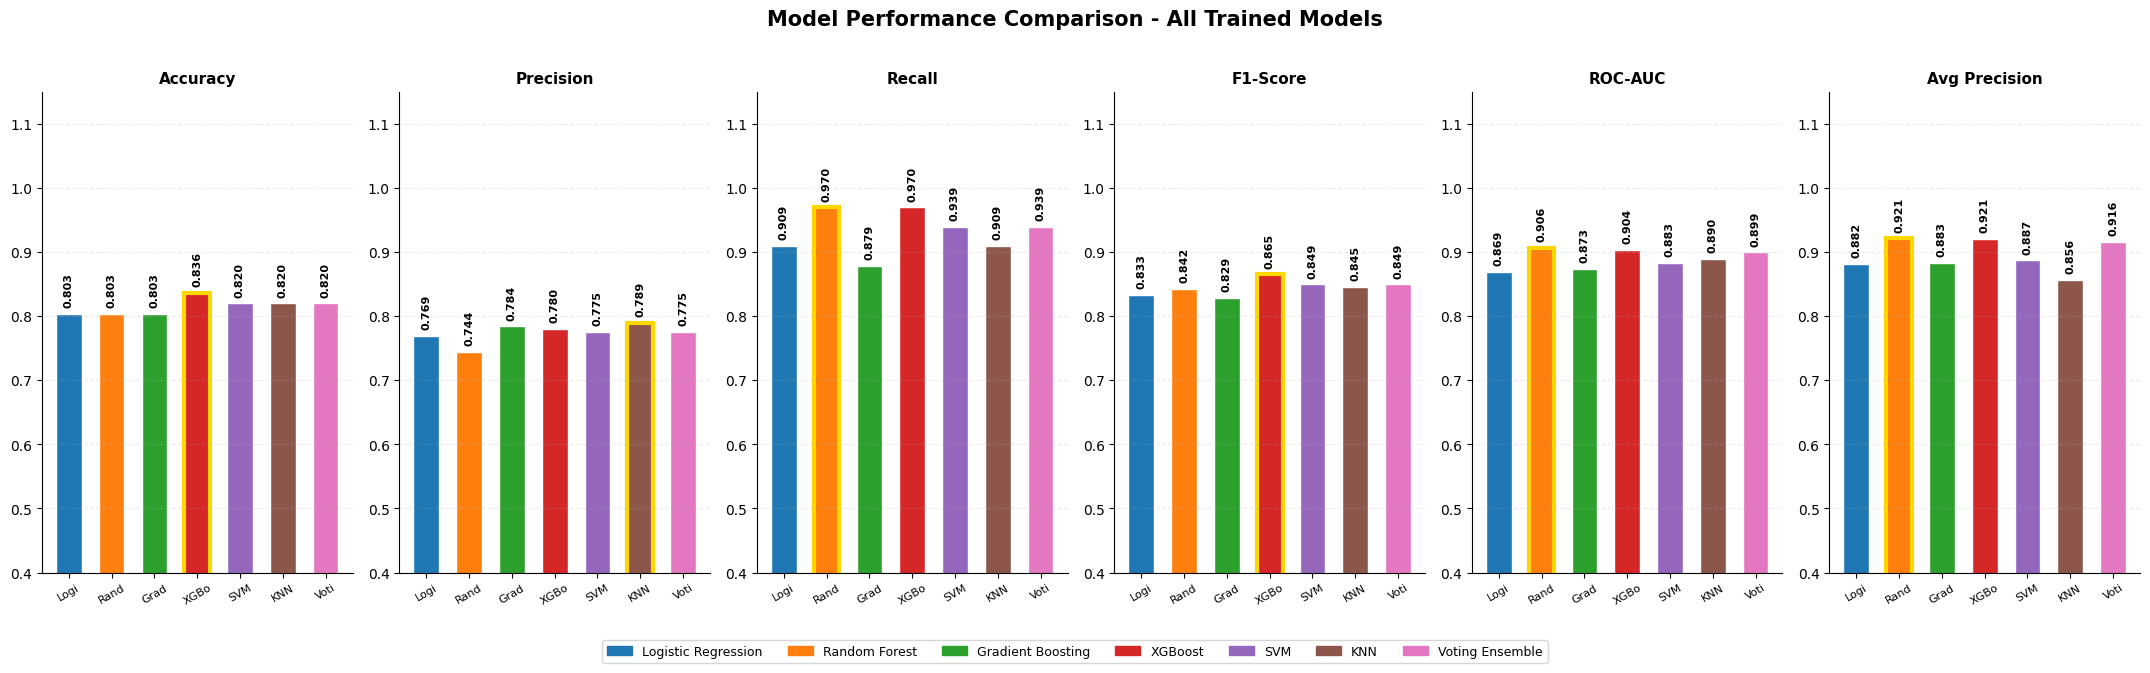


Model Comparison Summary:
Model                   Accuracy  Precision   Recall       F1      AUC   AvgPrec
--------------------------------------------------------------------------------
Logistic Regression        0.803      0.769    0.909    0.833    0.869     0.882
Random Forest              0.803      0.744    0.970    0.842    0.906     0.921
Gradient Boosting          0.803      0.784    0.879    0.829    0.873     0.883
XGBoost                    0.836      0.780    0.970    0.865    0.904     0.921
SVM                        0.820      0.775    0.939    0.849    0.883     0.887
KNN                        0.820      0.789    0.909    0.845    0.890     0.856
Voting Ensemble            0.820      0.775    0.939    0.849    0.899     0.916


In [13]:
# CELL 13 - Model comparison bar chart (6 metrics, generalized colors)
metrics = ["accuracy", "precision", "recall", "f1_score", "roc_auc", "avg_precision"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "Avg Precision"]

palette = cm.get_cmap("tab10")
MODEL_PALETTE = [palette(i % 10) for i in range(len(model_names))]

fig, axes = plt.subplots(1, len(metrics), figsize=(3.6 * len(metrics), 6))
fig.suptitle("Model Performance Comparison - All Trained Models", fontsize=15, fontweight="bold", y=1.02)

for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[i]
    values = [results[m][metric] for m in model_names]
    bars = ax.bar(range(len(model_names)), values, color=MODEL_PALETTE, edgecolor="white", width=0.6)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold", rotation=90)
    ax.set_title(label, fontweight="bold", fontsize=11)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels([n.split()[0][:4] for n in model_names], fontsize=8, rotation=30)
    ax.set_ylim(0.4, 1.15)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linestyle="--")
    best_idx = int(np.argmax(values))
    bars[best_idx].set_edgecolor("#FFD700"); bars[best_idx].set_linewidth(3)

legend_patches = [plt.Rectangle((0, 0), 1, 1, color=MODEL_PALETTE[i], label=model_names[i]) for i in range(len(model_names))]
fig.legend(handles=legend_patches, loc="lower center", ncol=len(model_names), bbox_to_anchor=(0.5, -0.08), fontsize=9)

plt.tight_layout()
plt.savefig("/content/model_comparison.png", dpi=120, bbox_inches="tight", facecolor="white")
plt.show()

print("\nModel Comparison Summary:")
print(f"{'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8} {'AvgPrec':>9}")
print("-" * 80)
for name in model_names:
    r = results[name]
    print(f"{name:<22} {r['accuracy']:>9.3f} {r['precision']:>10.3f} {r['recall']:>8.3f} "
          f"{r['f1_score']:>8.3f} {r['roc_auc']:>8.3f} {r['avg_precision']:>9.3f}")


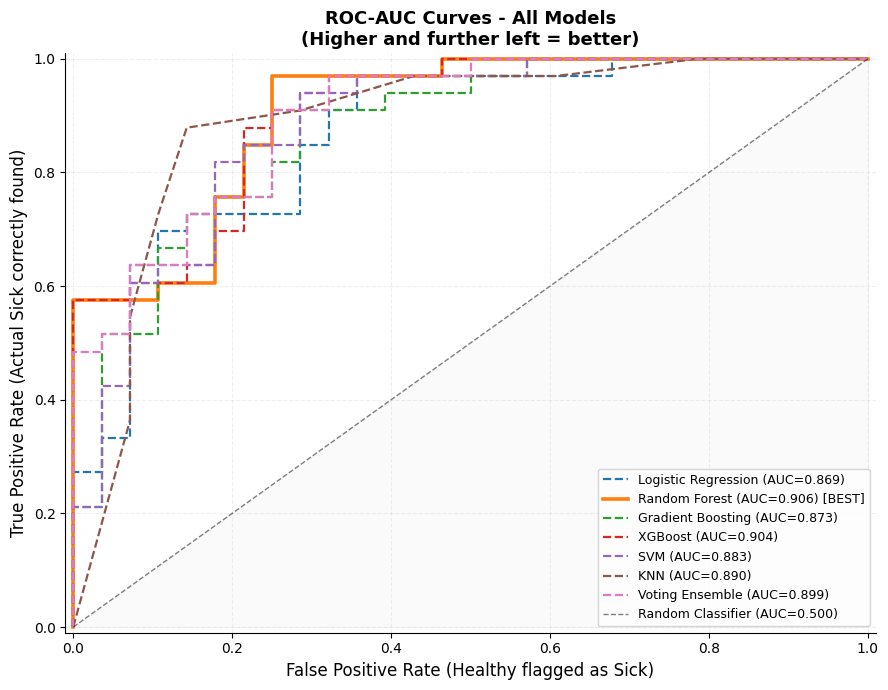

In [14]:
# CELL 14 - ROC-AUC curves (generalized)
fig, ax = plt.subplots(figsize=(9, 7))
for i, name in enumerate(model_names):
    fpr, tpr, _ = roc_curve(y_test, results[name]["y_pred_prob"])
    is_best = name == BEST_MODEL_NAME
    ax.plot(fpr, tpr, color=MODEL_PALETTE[i], linewidth=2.6 if is_best else 1.6,
            linestyle="-" if is_best else "--",
            label=f"{name} (AUC={results[name]['roc_auc']:.3f})" + (" [BEST]" if is_best else ""))

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random Classifier (AUC=0.500)")
ax.fill_between([0, 1], [0, 1], alpha=0.04, color="gray")
ax.set_xlabel("False Positive Rate (Healthy flagged as Sick)", fontsize=12)
ax.set_ylabel("True Positive Rate (Actual Sick correctly found)", fontsize=12)
ax.set_title("ROC-AUC Curves - All Models\n(Higher and further left = better)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.2, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
plt.savefig("/content/roc_curves.png", dpi=120, bbox_inches="tight", facecolor="white")
plt.show()


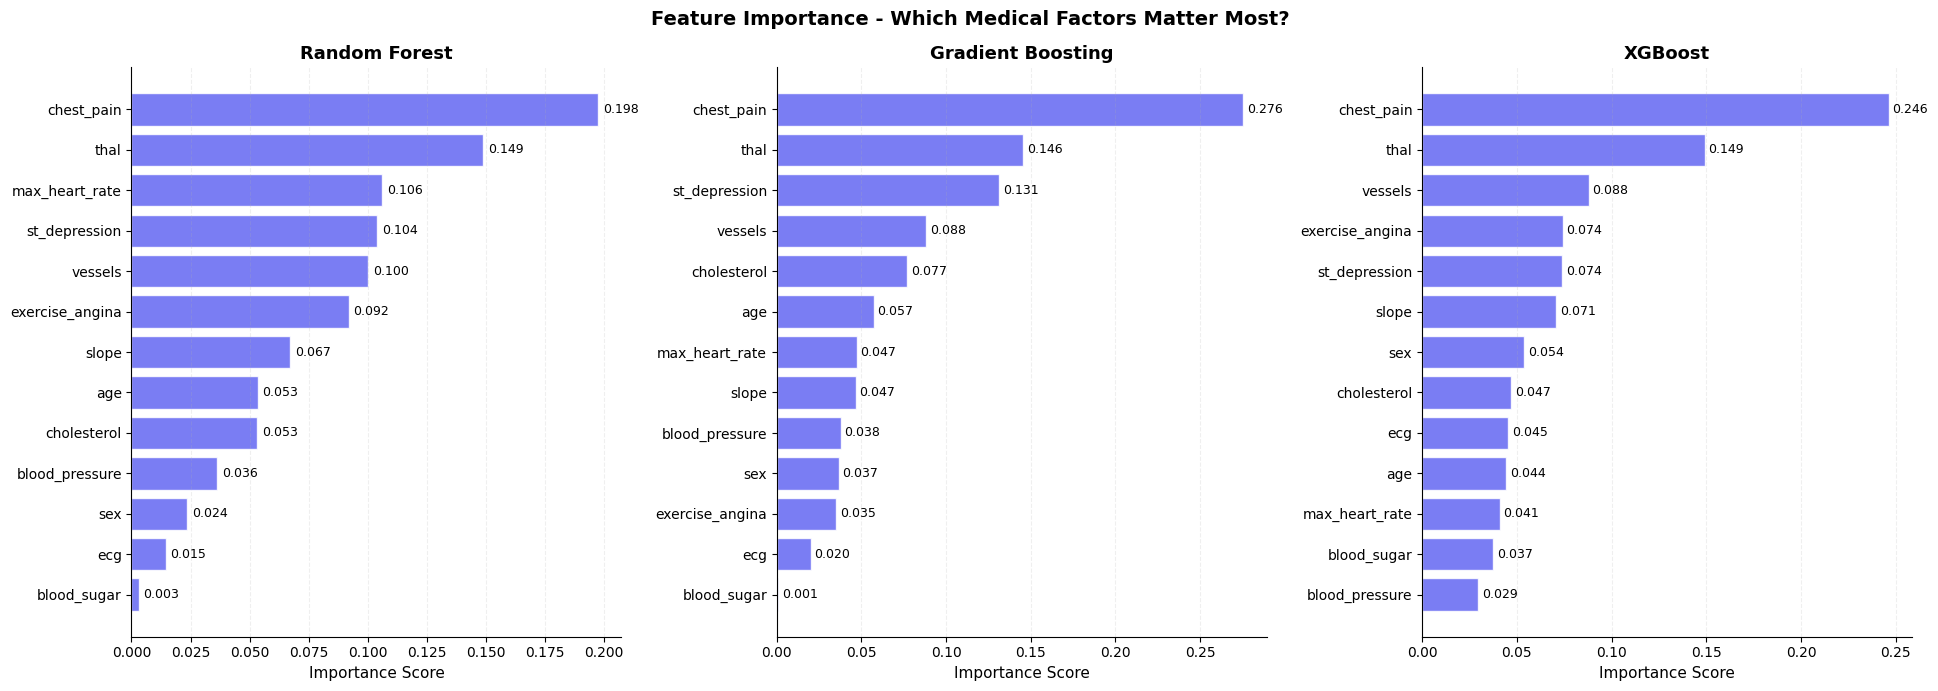

Top 5 features (Random Forest):
  1. chest_pain          : 0.198
  2. thal                : 0.149
  3. max_heart_rate      : 0.106
  4. st_depression       : 0.104
  5. vessels             : 0.100


In [15]:
# CELL 15 - Feature importance (auto-detects every tree-based model)
def _unwrap(model):
    return model.named_steps["clf"] if hasattr(model, "named_steps") else model

tree_based = {name: _unwrap(m) for name, m in trained_models.items() if hasattr(_unwrap(m), "feature_importances_")}
n_tree = len(tree_based)

fig, axes = plt.subplots(1, n_tree, figsize=(6.5 * n_tree, 7))
if n_tree == 1:
    axes = [axes]
fig.suptitle("Feature Importance - Which Medical Factors Matter Most?", fontsize=14, fontweight="bold")

for ax, (name, inner_model) in zip(axes, tree_based.items()):
    importances = inner_model.feature_importances_
    indices = np.argsort(importances)
    feat_names = [FEATURE_NAMES[i] for i in indices]
    bars = ax.barh(range(len(indices)), importances[indices], color=COLORS["primary"], alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, importances[indices]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2, f"{val:.3f}", va="center", fontsize=9)
    ax.set_yticks(range(len(indices))); ax.set_yticklabels(feat_names, fontsize=10)
    ax.set_xlabel("Importance Score", fontsize=11); ax.set_title(name, fontweight="bold", fontsize=13)
    ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="x", alpha=0.2, linestyle="--")

plt.tight_layout()
plt.savefig("/content/feature_importance.png", dpi=120, bbox_inches="tight", facecolor="white")
plt.show()

rf_importances = tree_based.get("Random Forest")
if rf_importances is not None:
    top5_idx = np.argsort(rf_importances.feature_importances_)[::-1][:5]
    print("Top 5 features (Random Forest):")
    for rank, idx in enumerate(top5_idx, 1):
        print(f"  {rank}. {FEATURE_NAMES[idx]:<20}: {rf_importances.feature_importances_[idx]:.3f}")


Deep evaluation of best model: Random Forest
-------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.94      0.61      0.74        28
Heart Disease       0.74      0.97      0.84        33

     accuracy                           0.80        61
    macro avg       0.84      0.79      0.79        61
 weighted avg       0.84      0.80      0.79        61

5-Fold Cross Validation:
  Scores : [0.836 0.885 0.836 0.85  0.767]
  Mean   : 0.835 +/- 0.039


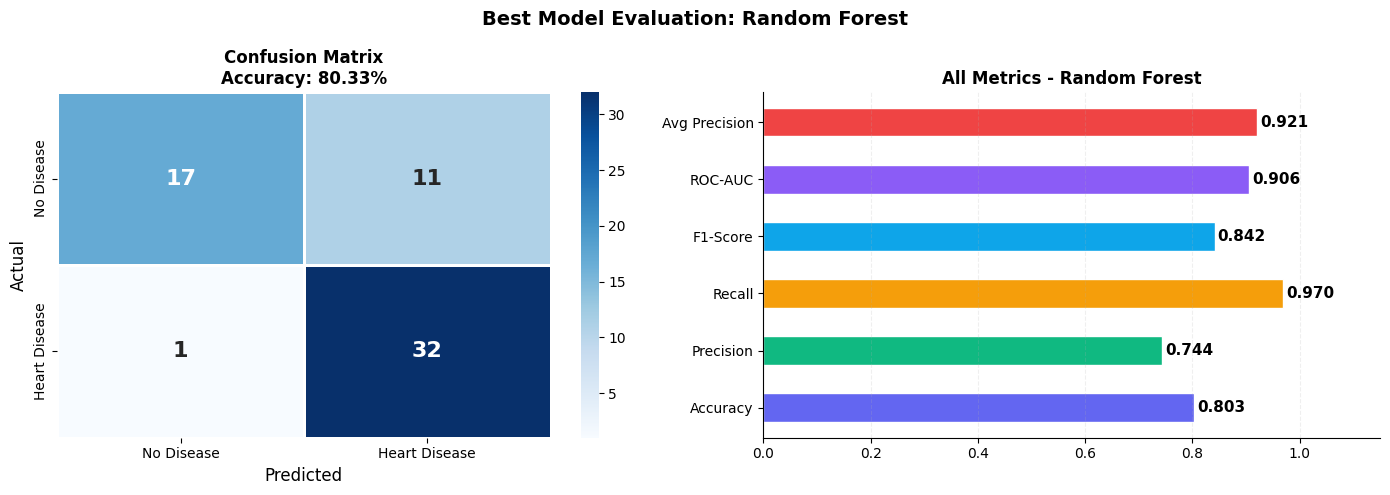


TP (correct disease)     : 32
TN (correct no-disease)  : 17
FP (healthy flagged sick): 11
FN (disease cases missed): 1


In [16]:
# CELL 16 - Best model deep evaluation: classification report, cross-val, confusion matrix
best_y_pred = results[BEST_MODEL_NAME]["y_pred"]

print(f"Deep evaluation of best model: {BEST_MODEL_NAME}")
print("-" * 55)
print("\nClassification Report:")
print(classification_report(y_test, best_y_pred, target_names=["No Disease", "Heart Disease"]))

# Cross-validation - no branching needed, the pipeline handles scaling internally
print("5-Fold Cross Validation:")
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="accuracy")
print(f"  Scores : {cv_scores.round(3)}")
print(f"  Mean   : {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

cm = confusion_matrix(y_test, best_y_pred)
tn, fp, fn, tp = cm.ravel()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Best Model Evaluation: {BEST_MODEL_NAME}", fontsize=14, fontweight="bold")

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax1,
            xticklabels=["No Disease", "Heart Disease"], yticklabels=["No Disease", "Heart Disease"],
            linewidths=1, linecolor="white", annot_kws={"size": 16, "weight": "bold"})
ax1.set_xlabel("Predicted", fontsize=12); ax1.set_ylabel("Actual", fontsize=12)
ax1.set_title(f"Confusion Matrix\nAccuracy: {accuracy_score(y_test, best_y_pred)*100:.2f}%", fontweight="bold", fontsize=12)

metric_vals = [results[BEST_MODEL_NAME][m] for m in metrics]
bars = ax2.barh(metric_labels, metric_vals,
                 color=[COLORS["primary"], COLORS["success"], COLORS["warning"], COLORS["info"], COLORS["purple"], COLORS["danger"]],
                 edgecolor="white", height=0.5)
for bar, val in zip(bars, metric_vals):
    ax2.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2, f"{val:.3f}", va="center", fontweight="bold", fontsize=11)
ax2.set_xlim(0, 1.15); ax2.set_title(f"All Metrics - {BEST_MODEL_NAME}", fontweight="bold", fontsize=12)
ax2.spines[["top", "right"]].set_visible(False); ax2.grid(axis="x", alpha=0.2, linestyle="--")

plt.tight_layout()
plt.savefig("/content/best_model_evaluation.png", dpi=120, bbox_inches="tight", facecolor="white")
plt.show()

print(f"\nTP (correct disease)     : {tp}")
print(f"TN (correct no-disease)  : {tn}")
print(f"FP (healthy flagged sick): {fp}")
print(f"FN (disease cases missed): {fn}")


## Part 6 — Save Model Artifacts

In [17]:
# CELL 17 - Save every trained model + a JSON model card
os.makedirs("/content/models", exist_ok=True)
for name, model in trained_models.items():
    safe_name = name.lower().replace(" ", "_")
    joblib.dump(model, f"/content/models/{safe_name}.joblib")

model_card = {
    "project": PROJECT_TITLE,
    "developer": DEVELOPER_NAME,
    "task": "CodeAlpha ML Internship - Task 4: Disease Prediction",
    "dataset": "Cleveland Heart Disease (UCI)",
    "n_patients": int(len(df)),
    "n_features": len(FEATURE_NAMES),
    "feature_names": FEATURE_NAMES,
    "best_model": BEST_MODEL_NAME,
    "advanced_tuning": ADVANCED_TUNING,
    "shap_available": SHAP_AVAILABLE,
    "results": {name: {k: float(v) for k, v in r.items() if k not in ("y_pred", "y_pred_prob")}
                for name, r in results.items()},
    "trained_at": time.strftime("%Y-%m-%d %H:%M:%S"),
}
with open("/content/models/model_card.json", "w") as f:
    json.dump(model_card, f, indent=2)

print("Saved all models to /content/models/")
print("Saved model card -> /content/models/model_card.json")


Saved all models to /content/models/
Saved model card -> /content/models/model_card.json


## Part 7 — Explainability Engine
Every prediction comes with the top factors that drove it. If SHAP is
installed and the selected model is tree-based, real SHAP values are used.
Otherwise a dependency-free fallback estimates each feature's contribution
from (model feature importance) x (how unusual the patient's value is
compared to the training population) — so the app always explains itself,
with no hard dependency on SHAP.

In [18]:
# CELL 18 - Risk category bands + explainability functions
def risk_category(probability):
    pct = probability * 100
    if pct < 20:
        return "Low Risk", COLORS["success"]
    elif pct < 45:
        return "Mild Risk", COLORS["warning"]
    elif pct < 70:
        return "Moderate Risk", "#F97316"
    else:
        return "High Risk", COLORS["danger"]


def get_top_contributing_factors(model_name, feature_values, n=5):
    """Returns [(feature_name, contribution_score, patient_value), ...]"""
    model = trained_models[model_name]
    patient_df = pd.DataFrame([feature_values], columns=FEATURE_NAMES)
    inner_model = _unwrap(model)

    if SHAP_AVAILABLE and hasattr(inner_model, "feature_importances_") and not hasattr(model, "named_steps"):
        try:
            explainer = shap.TreeExplainer(inner_model)
            shap_values = explainer.shap_values(patient_df)
            sv = shap_values[1][0] if isinstance(shap_values, list) else np.array(shap_values)[0]
            idx = np.argsort(np.abs(sv))[::-1][:n]
            return [(FEATURE_NAMES[i], float(abs(sv[i])), float(feature_values[i])) for i in idx]
        except Exception:
            pass

    # Fallback: importance-weighted deviation from the typical training patient
    if hasattr(inner_model, "feature_importances_"):
        importances = inner_model.feature_importances_
    elif hasattr(inner_model, "coef_"):
        importances = np.abs(inner_model.coef_[0])
    else:
        importances = _unwrap(trained_models["Random Forest"]).feature_importances_

    z = (pd.Series(feature_values, index=FEATURE_NAMES) - TRAIN_MEAN) / TRAIN_STD
    contrib = np.abs(importances) * np.abs(z.values)
    idx = np.argsort(contrib)[::-1][:n]
    return [(FEATURE_NAMES[i], float(contrib[i]), float(feature_values[i])) for i in idx]

print("Explainability engine ready" + (" (SHAP-backed for tree models)" if SHAP_AVAILABLE else " (fallback heuristic mode)"))


Explainability engine ready (SHAP-backed for tree models)


In [19]:
# CELL 19 - Visual risk gauge (semicircle meter, returned as a PIL image)
def create_risk_gauge(probability):
    fig, ax = plt.subplots(figsize=(5, 3), subplot_kw={"aspect": "equal"})
    bands = [(0, 20, COLORS["success"]), (20, 45, COLORS["warning"]), (45, 70, "#F97316"), (70, 100, COLORS["danger"])]
    for lo, hi, color in bands:
        theta1 = 180 - hi / 100 * 180
        theta2 = 180 - lo / 100 * 180
        ax.add_patch(Wedge((0, 0), 1.0, theta1, theta2, width=0.35, facecolor=color, edgecolor="white", linewidth=1.5))

    angle_rad = np.radians(180 - probability * 180)
    ax.plot([0, 0.8 * np.cos(angle_rad)], [0, 0.8 * np.sin(angle_rad)], color="#1F2937", linewidth=3, solid_capstyle="round")
    ax.add_patch(Circle((0, 0), 0.05, color="#1F2937"))
    ax.text(0, -0.35, f"{probability*100:.1f}%", ha="center", fontsize=20, fontweight="bold", color="#1F2937")
    ax.text(0, -0.55, "Disease Risk", ha="center", fontsize=11, color="#6B7280")
    ax.set_xlim(-1.1, 1.1); ax.set_ylim(-0.65, 1.1)
    ax.axis("off")

    buf = io.BytesIO()
    plt.tight_layout()
    plt.savefig(buf, format="png", dpi=110, bbox_inches="tight", transparent=True)
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf)

_test_gauge = create_risk_gauge(0.65)
print("Risk gauge generator ready")


Risk gauge generator ready


## Part 8 — Prediction Engine
A single `run_prediction()` core function is reused by the interactive
predictor, the downloadable report generator, and the batch CSV tool — one
source of truth, no duplicated logic.

In [20]:
# CELL 20 - Feature UI metadata + core prediction logic
FEATURE_INFO = {
    "age": ("Age (years)", 20, 100, 55),
    "sex": ("Sex (0=Female, 1=Male)", 0, 1, 1),
    "chest_pain": ("Chest Pain Type (0-3)", 0, 3, 1),
    "blood_pressure": ("Resting Blood Pressure (mm Hg)", 80, 200, 130),
    "cholesterol": ("Serum Cholesterol (mg/dl)", 100, 600, 245),
    "blood_sugar": ("Fasting Blood Sugar >120 mg/dl", 0, 1, 0),
    "ecg": ("Resting ECG (0-2)", 0, 2, 1),
    "max_heart_rate": ("Max Heart Rate Achieved", 60, 220, 150),
    "exercise_angina": ("Exercise-Induced Angina (0/1)", 0, 1, 0),
    "st_depression": ("ST Depression (oldpeak)", 0.0, 7.0, 1.0),
    "slope": ("Slope of ST Segment (0-2)", 0, 2, 1),
    "vessels": ("No. of Major Vessels (0-3)", 0, 3, 0),
    "thal": ("Thal (0=Normal, 1=Fixed, 2=Reversible)", 0, 2, 1),
}
UI_FEATURES = [f for f in FEATURE_NAMES if f != "target"]
MODEL_CHOICES = ["\u2b50 Best Model (Auto)"] + model_names


def run_prediction(model_choice, threshold, feature_values):
    """Core prediction logic shared by the UI, report generator, and batch tool."""
    model_name = BEST_MODEL_NAME if model_choice.startswith("\u2b50") else model_choice
    model = trained_models[model_name]
    patient_df = pd.DataFrame([feature_values], columns=FEATURE_NAMES)
    proba = model.predict_proba(patient_df)[0]
    disease_prob, no_disease_prob = float(proba[1]), float(proba[0])
    prediction = 1 if disease_prob >= threshold else 0
    risk_label, risk_color = risk_category(disease_prob)
    factors = get_top_contributing_factors(model_name, feature_values, n=5)

    return {
        "model_name": model_name, "threshold": threshold,
        "disease_prob": disease_prob, "no_disease_prob": no_disease_prob,
        "prediction": prediction, "risk_label": risk_label, "risk_color": risk_color,
        "factors": factors,
        "feature_values": dict(zip(FEATURE_NAMES, feature_values)),
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    }

print("Prediction engine ready")


Prediction engine ready


In [21]:
# CELL 21 - UI-facing prediction wrapper (with session history)
def predict_disease_ui(model_choice, threshold, *args):
    *feature_values, history = args
    try:
        result = run_prediction(model_choice, threshold, list(feature_values))
    except Exception as e:
        empty_hist_df = pd.DataFrame(history) if history else pd.DataFrame(columns=["Time", "Model", "Risk %", "Verdict"])
        return f"Prediction error: {e}", {}, None, "", history, empty_hist_df

    verdict = "Heart Disease Risk Detected" if result["prediction"] == 1 else "No Heart Disease Detected"
    icon = "\u26a0\ufe0f" if result["prediction"] == 1 else "\u2705"
    advice = ("Please consult a cardiologist for a full evaluation."
              if result["prediction"] == 1 else
              "Results look healthy - keep up a heart-healthy lifestyle.")

    result_text = (
        f"{icon} {verdict}\n\n"
        f"Model used         : {result['model_name']}\n"
        f"Decision threshold : {threshold:.2f}\n"
        f"Disease Risk       : {result['disease_prob']*100:.1f}%\n"
        f"Healthy Chance     : {result['no_disease_prob']*100:.1f}%\n"
        f"Risk Category      : {result['risk_label']}\n\n"
        f"{advice}\n\n"
        f"This is an AI-based educational prediction, NOT a medical diagnosis."
    )

    probs_dict = {"No Disease": round(result["no_disease_prob"], 4), "Heart Disease": round(result["disease_prob"], 4)}
    gauge_img = create_risk_gauge(result["disease_prob"])

    factors_md = "### Top Contributing Factors\n\n| Feature | Patient Value | Influence |\n|---|---|---|\n"
    max_score = max([f[1] for f in result["factors"]] + [1e-9])
    for fname, score, val in result["factors"]:
        label = FEATURE_INFO.get(fname, (fname,))[0]
        bar_len = max(1, int(score / max_score * 12))
        factors_md += f"| {label} | {val:g} | {'\u2588' * bar_len} `{score:.3f}` |\n"

    history_entry = {"Time": result["timestamp"], "Model": result["model_name"],
                      "Risk %": f"{result['disease_prob']*100:.1f}", "Verdict": verdict}
    new_history = history + [history_entry]
    return result_text, probs_dict, gauge_img, factors_md, new_history, pd.DataFrame(new_history)


def clear_history():
    return [], pd.DataFrame(columns=["Time", "Model", "Risk %", "Verdict"])

print("UI prediction wrapper ready")


UI prediction wrapper ready


In [22]:
# CELL 22 - Downloadable text report (NEW FEATURE)
def generate_report(model_choice, threshold, *feature_values):
    try:
        result = run_prediction(model_choice, threshold, list(feature_values))
    except Exception:
        return None

    lines = []
    lines.append("=" * 62)
    lines.append(f"   {PROJECT_TITLE.upper()} - RISK ASSESSMENT REPORT")
    lines.append(f"   Developer: {DEVELOPER_NAME} | CodeAlpha ML Internship - Task 4")
    lines.append("=" * 62)
    lines.append(f"Generated at : {result['timestamp']}")
    lines.append(f"Model used   : {result['model_name']}")
    lines.append(f"Threshold    : {threshold:.2f}")
    lines.append("")
    lines.append("PATIENT INPUT VALUES")
    lines.append("-" * 62)
    for fname, val in result["feature_values"].items():
        label = FEATURE_INFO.get(fname, (fname,))[0]
        lines.append(f"  {label:<42}: {val}")
    lines.append("")
    lines.append("PREDICTION RESULT")
    lines.append("-" * 62)
    verdict = "HEART DISEASE RISK DETECTED" if result["prediction"] == 1 else "NO HEART DISEASE DETECTED"
    lines.append(f"  Verdict             : {verdict}")
    lines.append(f"  Disease Probability : {result['disease_prob']*100:.1f}%")
    lines.append(f"  Healthy Probability : {result['no_disease_prob']*100:.1f}%")
    lines.append(f"  Risk Category       : {result['risk_label']}")
    lines.append("")
    lines.append("TOP CONTRIBUTING FACTORS")
    lines.append("-" * 62)
    for fname, score, val in result["factors"]:
        label = FEATURE_INFO.get(fname, (fname,))[0]
        lines.append(f"  {label:<42}: value={val:g}  influence={score:.3f}")
    lines.append("")
    lines.append("DISCLAIMER")
    lines.append("-" * 62)
    lines.append("  Generated by an AI model for educational purposes only.")
    lines.append("  This is NOT a medical diagnosis. Please consult a")
    lines.append("  qualified cardiologist for professional medical advice.")
    lines.append("=" * 62)

    out_path = "/content/heart_disease_report.txt"
    with open(out_path, "w") as f:
        f.write("\n".join(lines))
    return out_path

print("Report generator ready")


Report generator ready


In [23]:
# CELL 23 - Batch prediction from an uploaded CSV (NEW FEATURE)
def batch_predict_csv(file_obj, model_choice, threshold):
    if file_obj is None:
        return None, "Please upload a CSV file first.", None
    try:
        path = file_obj.name if hasattr(file_obj, "name") else file_obj
        batch_df = pd.read_csv(path)
    except Exception as e:
        return None, f"Could not read CSV: {e}", None

    X_batch = batch_df.reindex(columns=FEATURE_NAMES)
    for c in FEATURE_NAMES:
        X_batch[c] = pd.to_numeric(X_batch[c], errors="coerce")
        X_batch[c] = X_batch[c].fillna(TRAIN_MEAN[c])

    model_name = BEST_MODEL_NAME if model_choice.startswith("\u2b50") else model_choice
    model = trained_models[model_name]

    proba = model.predict_proba(X_batch)[:, 1]
    pred = (proba >= threshold).astype(int)

    out_df = batch_df.copy()
    out_df["Disease_Probability_%"] = (proba * 100).round(1)
    out_df["Prediction"] = np.where(pred == 1, "Heart Disease", "No Disease")
    out_df["Risk_Category"] = [risk_category(p)[0] for p in proba]

    out_path = "/content/batch_predictions_result.csv"
    out_df.to_csv(out_path, index=False)

    summary = (f"Processed {len(out_df)} patients with {model_name}. "
               f"Predicted disease: {int(pred.sum())} | Predicted healthy: {int((pred==0).sum())}")
    return out_df, summary, out_path

print("Batch prediction tool ready")


Batch prediction tool ready


## Part 9  User Interface
A custom-styled Gradio app: gradient header banner, metric badge chips, and
the developer's name shown clearly at both the top and bottom of the page.

In [24]:
# CELL 24 - Custom CSS theme
CUSTOM_CSS = """
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600;700;800&family=Inter:wght@400;500;600&display=swap');

.gradio-container { font-family: 'Inter', sans-serif; }
h1, h2, h3 { font-family: 'Poppins', sans-serif; }

.hero-header {
    background: linear-gradient(135deg, #4338CA 0%, #6D28D9 50%, #DB2777 100%);
    padding: 30px 34px;
    border-radius: 18px;
    color: white !important;
    margin-bottom: 16px;
    box-shadow: 0 10px 30px rgba(76, 29, 149, 0.25);
}
.hero-header h1 { margin: 0 0 6px 0 !important; font-size: 28px !important; font-weight: 800 !important; color: white !important; }
.hero-header p { margin: 3px 0 !important; opacity: 0.95; color: white !important; }
.dev-badge {
    display: inline-block;
    background: rgba(255,255,255,0.18);
    border: 1px solid rgba(255,255,255,0.4);
    padding: 5px 16px;
    border-radius: 999px;
    font-weight: 700;
    font-size: 13px;
    margin-top: 12px;
    color: white !important;
}
.metric-row { display: flex; gap: 10px; flex-wrap: wrap; margin-top: 14px; }
.metric-chip {
    background: rgba(255,255,255,0.15);
    border-radius: 12px; padding: 8px 16px;
    font-weight: 600; font-size: 13px; color: white !important;
    border: 1px solid rgba(255,255,255,0.3);
}
.app-footer {
    text-align: center; padding: 18px 0 6px 0;
    color: #6B7280; font-size: 13px; border-top: 1px solid #E5E7EB; margin-top: 16px;
}
.app-footer b { color: #4338CA; }
"""
print("Custom CSS theme ready")


Custom CSS theme ready


In [25]:
# CELL 25 - Build the app
def build_app():
    with gr.Blocks(title=f"{PROJECT_TITLE} - CodeAlpha Task 4", theme=gr.themes.Soft(primary_hue="indigo"), css=CUSTOM_CSS) as demo:

        gr.HTML(f"""
        <div class="hero-header">
            <h1>\U0001f3e5 {PROJECT_TITLE}</h1>
            <p>CodeAlpha Machine Learning Internship &mdash; Task 4 (Advanced Edition)</p>
            <p>{len(models)} ML models trained &amp; compared on the Cleveland Heart Disease dataset</p>
            <div class="metric-row">
                <div class="metric-chip">\U0001f3c6 Best Model: {BEST_MODEL_NAME}</div>
                <div class="metric-chip">\U0001f4c8 AUC: {results[BEST_MODEL_NAME]['roc_auc']:.3f}</div>
                <div class="metric-chip">\u2705 Accuracy: {results[BEST_MODEL_NAME]['accuracy']*100:.1f}%</div>
                <div class="metric-chip">\U0001f465 {len(df)} Patients</div>
            </div>
            <div class="dev-badge">\U0001f468\u200d\U0001f4bb Developed by {DEVELOPER_NAME}</div>
        </div>
        """)

        history_state = gr.State([])

        with gr.Tabs():
            # ══════════════════════ TAB 1: PREDICT ══════════════════════
            with gr.TabItem("\U0001f50d Predict"):
                gr.Markdown("### Enter Patient Medical Details")
                with gr.Row():
                    model_dropdown = gr.Dropdown(choices=MODEL_CHOICES, value=MODEL_CHOICES[0], label="Model", scale=2)
                    threshold_slider = gr.Slider(0.05, 0.95, value=DEFAULT_THRESHOLD, step=0.05,
                                                  label="Decision Threshold (sensitivity)", scale=2)

                input_components = []
                with gr.Row():
                    with gr.Column(scale=1):
                        gr.Markdown("#### \U0001f464 Patient Profile")
                        for feat in UI_FEATURES[:4]:
                            label, mn, mx, default = FEATURE_INFO.get(feat, (feat, 0, 100, 50))
                            comp = gr.Slider(minimum=float(mn), maximum=float(mx), value=float(default),
                                              step=1.0 if mx - mn > 5 else 0.1, label=label)
                            input_components.append(comp)
                    with gr.Column(scale=1):
                        gr.Markdown("#### \U0001f493 Cardiac Measurements")
                        for feat in UI_FEATURES[4:8]:
                            label, mn, mx, default = FEATURE_INFO.get(feat, (feat, 0, 100, 50))
                            comp = gr.Slider(minimum=float(mn), maximum=float(mx), value=float(default),
                                              step=1.0 if mx - mn > 5 else 0.1, label=label)
                            input_components.append(comp)
                    with gr.Column(scale=1):
                        gr.Markdown("#### \U0001fac0 Exercise & Vessels")
                        for feat in UI_FEATURES[8:]:
                            label, mn, mx, default = FEATURE_INFO.get(feat, (feat, 0, 2, 0))
                            comp = gr.Slider(minimum=float(mn), maximum=float(mx), value=float(default),
                                              step=1.0 if mx - mn > 5 else 0.1, label=label)
                            input_components.append(comp)

                with gr.Row():
                    predict_btn = gr.Button("\U0001f50d Predict Heart Disease Risk", variant="primary", size="lg")
                    report_btn = gr.Button("\U0001f4c4 Download Report", size="lg")

                with gr.Row():
                    with gr.Column(scale=1):
                        output_text = gr.Textbox(label="\U0001f4cb Prediction Result", lines=9)
                        output_probs = gr.Label(label="\U0001f4ca Probability Scores", num_top_classes=2)
                    with gr.Column(scale=1):
                        output_gauge = gr.Image(label="\U0001f3af Risk Meter", height=260)
                        output_factors = gr.Markdown()

                report_file = gr.File(label="Downloaded Report", visible=True)

                gr.Markdown("### \U0001f4a1 Example Patient Profiles")
                example_data = [[float(row[f]) for f in FEATURE_NAMES] for _, row in df.head(6).iterrows()]
                gr.Examples(examples=example_data, inputs=input_components, label="Click to load a real patient profile")

            # ══════════════════════ TAB 2: BATCH PREDICT ══════════════════════
            with gr.TabItem("\U0001f4c1 Batch Predict"):
                gr.Markdown(f"""
                ### Predict for Many Patients at Once
                Upload a CSV with these {len(FEATURE_NAMES)} columns: `{", ".join(FEATURE_NAMES)}`.
                Missing columns are filled with the training-set average.
                """)
                with gr.Row():
                    batch_model_dropdown = gr.Dropdown(choices=MODEL_CHOICES, value=MODEL_CHOICES[0], label="Model")
                    batch_threshold_slider = gr.Slider(0.05, 0.95, value=DEFAULT_THRESHOLD, step=0.05, label="Decision Threshold")
                batch_file_input = gr.File(label="Upload patient CSV", file_types=[".csv"])
                batch_run_btn = gr.Button("\U0001f680 Run Batch Prediction", variant="primary")
                batch_summary = gr.Textbox(label="Summary", lines=2)
                batch_preview = gr.Dataframe(label="Results Preview", wrap=True)
                batch_download = gr.File(label="Download Full Results (CSV)")

            # ══════════════════════ TAB 3: MODEL COMPARISON ══════════════════════
            with gr.TabItem("\U0001f4ca Model Comparison"):
                gr.Markdown(f"### All {len(models)} Models Trained and Compared\n**Winner: {BEST_MODEL_NAME}** (AUC = {results[BEST_MODEL_NAME]['roc_auc']:.3f})")
                with gr.Row():
                    gr.Image(value="/content/model_comparison.png", label="Model Comparison - All Metrics")
                    gr.Image(value="/content/roc_curves.png", label="ROC-AUC Curves")

                table_md = "| Model | Accuracy | Precision | Recall | F1 | AUC | Avg Precision |\n"
                table_md += "|---|---|---|---|---|---|---|\n"
                for name in model_names:
                    r = results[name]
                    star = " \U0001f3c6" if name == BEST_MODEL_NAME else ""
                    table_md += (f"| {name}{star} | {r['accuracy']:.3f} | {r['precision']:.3f} | "
                                 f"{r['recall']:.3f} | {r['f1_score']:.3f} | {r['roc_auc']:.3f} | {r['avg_precision']:.3f} |\n")
                gr.Markdown(table_md)

            # ══════════════════════ TAB 4: FEATURE IMPORTANCE ══════════════════════
            with gr.TabItem("\U0001f511 Feature Importance"):
                gr.Markdown("### Which Medical Features Predict Heart Disease Best?")
                gr.Image(value="/content/feature_importance.png", label="Feature Importance - All Tree-Based Models")
                gr.Image(value="/content/best_model_evaluation.png", label=f"Best Model ({BEST_MODEL_NAME}) - Confusion Matrix & Metrics")

            # ══════════════════════ TAB 5: DATA EXPLORATION ══════════════════════
            with gr.TabItem("\U0001f4c8 Data Exploration"):
                gr.Markdown("### Heart Disease Dataset - Exploratory Data Analysis")
                gr.Image(value="/content/eda_charts.png", label="EDA Dashboard")
                gr.Markdown(f"""
| Property | Value |
|---|---|
| Total patients | **{len(df)}** |
| Features | **{len(FEATURE_NAMES)}** |
| Heart Disease cases | **{disease_count} ({disease_count/total*100:.1f}%)** |
| No Disease cases | **{no_disease_count} ({no_disease_count/total*100:.1f}%)** |
| Training samples | **{len(X_train)}** |
| Test samples | **{len(X_test)}** |
| Source | **Cleveland Heart Disease (UCI)** |
                """)

            # ══════════════════════ TAB 6: PREDICTION HISTORY ══════════════════════
            with gr.TabItem("\U0001f553 Prediction History"):
                gr.Markdown("### Predictions Made This Session")
                history_table = gr.Dataframe(headers=["Time", "Model", "Risk %", "Verdict"], label="History")
                clear_history_btn = gr.Button("\U0001f5d1\ufe0f Clear History")

            # ══════════════════════ TAB 7: HOW IT WORKS ══════════════════════
            with gr.TabItem("\u2699\ufe0f How It Works"):
                gr.Markdown(f"""
## How This System Works

**Step 1 — Collect Patient Data.** {len(FEATURE_NAMES)} medical measurements per patient.

**Step 2 — Preprocess.** Every model that needs scaled input (Logistic
Regression, SVM, KNN) has its own `StandardScaler` built into an sklearn
`Pipeline`, so scaling always happens consistently, automatically, exactly
once.

**Step 3 — Train {len(models)} Models**

| Model | How it works |
|---|---|
| Logistic Regression | Finds a straight line/plane that separates the two groups |
| Random Forest | Builds 200+ decision trees and takes a majority vote |
| Gradient Boosting | Builds trees sequentially, each correcting the last |
| XGBoost | An optimized, regularized version of gradient boosting |
| SVM | Finds the widest possible margin between classes |
| KNN | Looks at the most similar patients in the training data |
| Voting Ensemble | Averages the probabilities of the top 4 models above |

**Step 4 — (Optional) Hyperparameter Tuning.** `RandomizedSearchCV` searches
for better Random Forest / XGBoost settings automatically.

**Step 5 — Pick the Best Model.** Compared on ROC-AUC using the 20% of data
no model has seen during training.

**Step 6 — Explain the Prediction.** SHAP values (if installed) or a
built-in fallback identify which patient measurements most influenced the
result.

**Step 7 — Predict.** `model.predict_proba(patient_data)` returns a
probability; the adjustable **threshold** decides the final Yes/No verdict.

> \u26a0\ufe0f This model is for educational purposes. A real clinical tool
> requires regulatory approval, larger datasets, and validation by medical
> professionals.
                """)

            # ══════════════════════ TAB 8: ABOUT / DEVELOPER ══════════════════════
            with gr.TabItem("\U0001f468\u200d\U0001f4bb About"):
                gr.Markdown(f"""
### About This Project

**{PROJECT_TITLE}** — an advanced heart-disease risk prediction system built
for the CodeAlpha Machine Learning Internship, Task 4.

**Developer:** {DEVELOPER_NAME}

**Tech stack:** Python &middot; Pandas &middot; scikit-learn &middot; XGBoost
&middot; SHAP &middot; Gradio &middot; Matplotlib &middot; Seaborn

**Dataset:** Cleveland Heart Disease Dataset (UCI Machine Learning Repository)

**What makes this version "advanced":**
- 7 trained models with a shared, bug-free preprocessing pipeline
- Optional automatic hyperparameter search
- Real explainability (SHAP + safe fallback)
- Adjustable decision threshold and model selector
- Batch CSV predictions and downloadable reports
- A redesigned, attractive interface

> \u26a0\ufe0f **Disclaimer:** This tool is for educational and
> demonstration purposes only and must never be used as a substitute for
> professional medical advice, diagnosis, or treatment.
                """)

        # ── Event bindings ──────────────────────────────────────
        # Wired up here, after every tab's components already exist,
        # so a component defined in a later tab (e.g. history_table in
        # "Prediction History") can safely be used as an output for a
        # button in an earlier tab (e.g. "Predict") with no forward-
        # reference errors.
        predict_btn.click(
            fn=predict_disease_ui,
            inputs=[model_dropdown, threshold_slider] + input_components + [history_state],
            outputs=[output_text, output_probs, output_gauge, output_factors, history_state, history_table],
        )
        report_btn.click(
            fn=generate_report,
            inputs=[model_dropdown, threshold_slider] + input_components,
            outputs=[report_file],
        )
        batch_run_btn.click(
            fn=batch_predict_csv,
            inputs=[batch_file_input, batch_model_dropdown, batch_threshold_slider],
            outputs=[batch_preview, batch_summary, batch_download],
        )
        clear_history_btn.click(fn=clear_history, outputs=[history_state, history_table])

        gr.HTML(f"""
        <div class="app-footer">
            \U0001fa7a {PROJECT_TITLE} &middot; Built with care by <b>{DEVELOPER_NAME}</b> &middot;
            CodeAlpha Machine Learning Internship &mdash; Task 4
        </div>
        """)

    return demo

print("App builder ready")


App builder ready


In [26]:
# CELL 26 - Launch
print(f"Launching {PROJECT_TITLE}...")
print(f"  Best model : {BEST_MODEL_NAME}")
print(f"  Best AUC   : {results[BEST_MODEL_NAME]['roc_auc']:.3f}")
print(f"  Best Acc   : {results[BEST_MODEL_NAME]['accuracy']:.3f}")
print(f"  Dataset    : {len(df)} patients x {len(FEATURE_NAMES)} features")
print(f"  Developer  : {DEVELOPER_NAME}\n")

app = build_app()
app.launch(share=True, debug=False, show_error=True, quiet=True)


Launching Heart Disease Prediction System...
  Best model : Random Forest
  Best AUC   : 0.906
  Best Acc   : 0.803
  Dataset    : 303 patients x 13 features
  Developer  : Taj Wali Khan

* Running on public URL: https://82ee7d8718743d5a31.gradio.live


### ✅ Testing checklist
- Load an example patient → click **Predict** → result, probability bars,
  risk gauge, and top contributing factors all appear.
- Change the **Decision Threshold** slider → verdict flips at the expected
  probability.
- Change the **Model** dropdown → prediction updates using that specific
  model.
- Click **Download Report** → a `.txt` file appears with the full patient
  summary.
- **Batch Predict** tab → upload a small CSV with the 13 feature columns →
  preview table + downloadable results CSV.
- **Model Comparison**, **Feature Importance**, **Data Exploration** tabs →
  all charts render.
- **Prediction History** tab → fills up as you make predictions; **Clear
  History** empties it.
- **About** tab → developer name **Taj Wali Khan** is visible.

### Expected results
- Best model accuracy : ~85–90% (real dataset) / near chance on the
  synthetic fallback dataset if all online sources are unreachable
- Best ROC-AUC score   : ~0.90–0.95 (real dataset)
- Total training time  : well under a minute for all 7 models with
  `ADVANCED_TUNING = True`
